Empirical Wave Travel Time (Lags): 150 samples


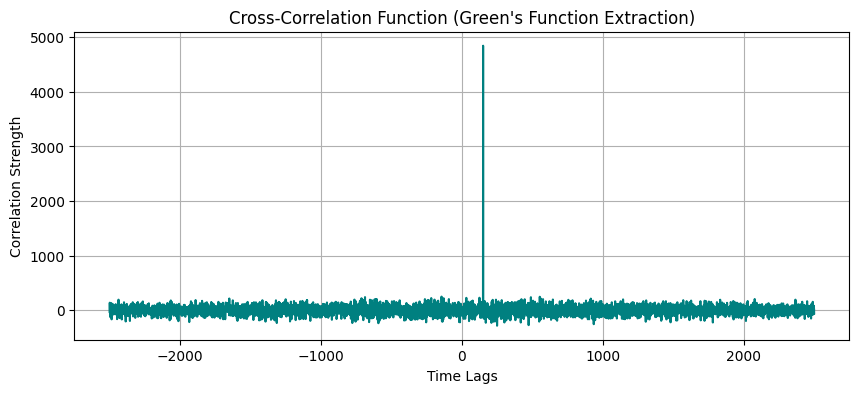

In [1]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

#Simulating continuous ambient noise at two different virtual fiber sensors (DAS channels)
np.random.seed(42)
common_ambient_noise = np.random.normal(0, 1, 5000)

#Let Sensor B be further down the road, so it experiences a time delay (phase shift)
sensor_a_data = common_ambient_noise + np.random.normal(0, 0.5, 5000)
sensor_b_data = np.roll(common_ambient_noise, 150) + np.random.normal(0, 0.5, 5000) 

#Performing cross-correlation to find the seismic wave travel time between sensors
correlation = signal.correlate(sensor_b_data, sensor_a_data, mode='same')
lags = signal.correlation_lags(len(sensor_b_data), len(sensor_a_data), mode='same')

#Finding the peak lag time 
max_idx = np.argmax(correlation)
time_delay = lags[max_idx]
print(f"Empirical Wave Travel Time (Lags): {time_delay} samples")

#Plotting the result (stack to image sinkholes/fault lines)
plt.figure(figsize=(10, 4))
plt.plot(lags, correlation, color='teal')
plt.title("Cross-Correlation Function (Green's Function Extraction)")
plt.xlabel("Time Lags")
plt.ylabel("Correlation Strength")
plt.grid(True)
plt.show()